# EP19 — Self-Supervised Learning (2025 Version)
**COMPSCI 713 · S1 2025 Q10 · 3 marks**

| Part | Topic | Marks |
|------|-------|-------|
| a-i | SSL vs Supervised Learning | 1 |
| a-ii | SSL vs Unsupervised Learning | 1 |
| b | How SSL contributes to AI sustainability | 1 |

*Note: EP07 covers pretext/downstream tasks for the 2024 exam. This EP adds the sustainability angle and sharper comparisons required by 2025 Q10.*

---

## Background: What is Self-Supervised Learning?

SSL learns representations from **unlabelled data** by solving **pretext tasks** — artificially constructed problems whose labels are derived automatically from the data structure itself.

Examples:
- **NLP:** predict masked words (BERT), predict next token (GPT)
- **Vision:** predict image rotation, reconstruct masked patches (MAE), match augmented views (SimCLR)

Goal: produce general-purpose representations that transfer to downstream tasks with little labelled data.

---

## Part (a-i) — SSL vs Supervised Learning [1 mark]

| Aspect | Supervised Learning | Self-Supervised Learning |
|--------|--------------------|--------------------------|
| **Source of supervision** | Human-annotated labels (external) | Auto-generated from data structure itself (internal) |
| **Learning objective** | Directly optimise target task (e.g., classify dog vs cat) | Solve a pretext task (e.g., predict masked token) to learn representations |
| **Scale** | Limited by annotation budget | Can exploit internet-scale unlabelled data |
| **Transferability** | Model is task-specific | Representations transfer to many downstream tasks |

**Key distinction:** Supervised learning uses *external human labels* as the supervision signal. SSL generates its own supervision *from the data's internal structure* — but still uses a supervised-style loss.

---

## Part (a-ii) — SSL vs Unsupervised Learning [1 mark]

| Aspect | Unsupervised Learning | Self-Supervised Learning |
|--------|----------------------|--------------------------|
| **Source of supervision** | No supervision signal at all | Auto-generated predictive target from data |
| **Learning objective** | Model data distribution/structure (e.g., clustering, density) | Solve a specific predictive task designed to encourage good representations |
| **Transfer quality** | Representations may not transfer well to arbitrary downstream tasks | Explicitly designed to produce transferable, general-purpose features |
| **Examples** | K-means, PCA, VAE, GMM, autoencoders | BERT, GPT, SimCLR, MAE, DINO |

**Key distinction:** Both avoid human labels, but unsupervised learning models the data distribution generically. SSL defines a *specific predictive objective* that drives the model to learn *structured, transferable* representations.

---

## Part (b) — SSL and AI Sustainability [1 mark]

SSL contributes to AI sustainability in two main ways:

### 1. Reducing data annotation cost
Creating large labelled datasets requires enormous human effort (time, money, expertise). SSL bypasses this by using unlabelled data — which is abundantly available at zero labelling cost — to train models that rival or exceed supervised baselines. This reduces the **human resource cost** of AI development and democratises access (organisations without annotation budgets can train competitive models).

### 2. Amortising training cost through reusable representations
A single SSL pre-trained model (e.g., BERT, GPT, ViT) can be fine-tuned for hundreds of different downstream tasks at a fraction of the cost of training each task from scratch. The massive pre-training computation is *shared across all downstream uses*. This means:
- Less total compute consumption per deployed model
- Fewer GPUs/energy per production application
- Lower carbon footprint for the AI ecosystem as a whole

**One-line exam answer:** SSL trains on free unlabelled data and produces reusable pre-trained models, reducing both annotation labour costs and the repeated compute cost of training task-specific models from scratch.

---

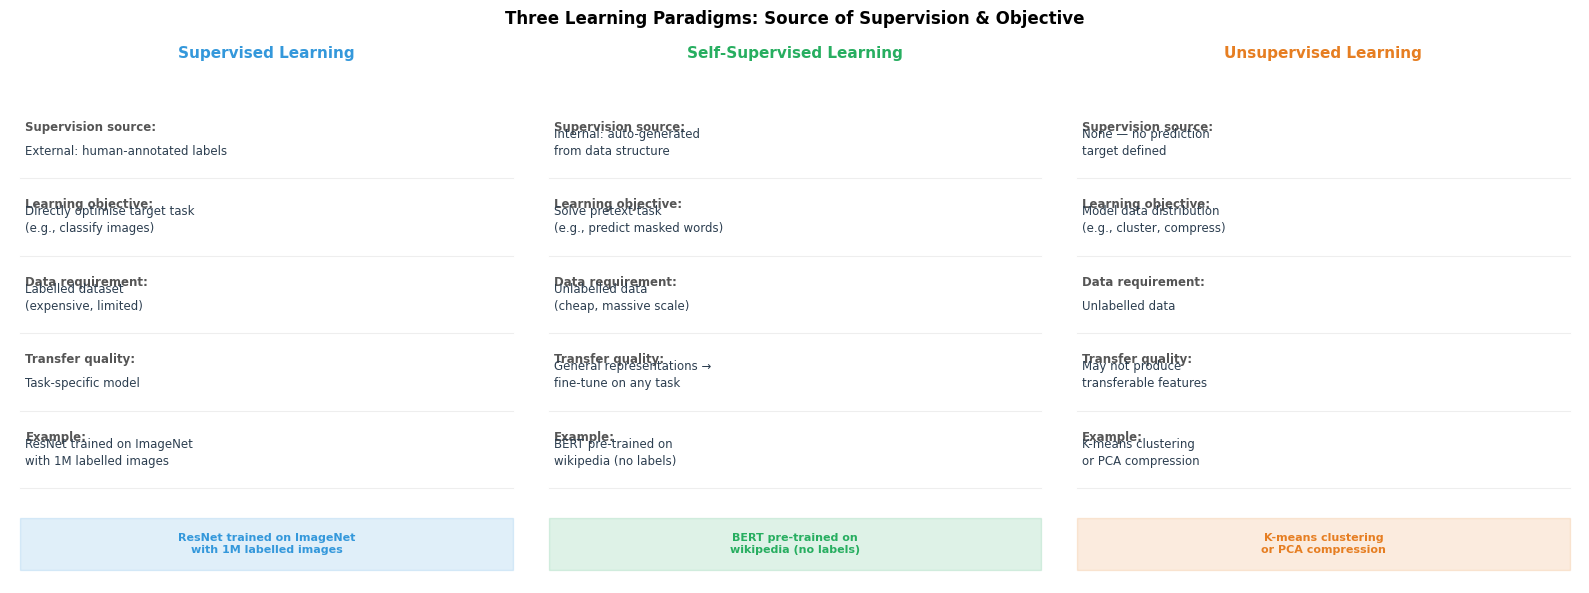

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

# =============================================================
# Visualisation 1: Three paradigm comparison
# =============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

paradigms = [
    {
        'title': 'Supervised Learning',
        'colour': '#3498db',
        'supervision': 'External: human-annotated labels',
        'objective': 'Directly optimise target task\n(e.g., classify images)',
        'data': 'Labelled dataset\n(expensive, limited)',
        'transfer': 'Task-specific model',
        'example': 'ResNet trained on ImageNet\nwith 1M labelled images',
    },
    {
        'title': 'Self-Supervised Learning',
        'colour': '#27ae60',
        'supervision': 'Internal: auto-generated\nfrom data structure',
        'objective': 'Solve pretext task\n(e.g., predict masked words)',
        'data': 'Unlabelled data\n(cheap, massive scale)',
        'transfer': 'General representations →\nfine-tune on any task',
        'example': 'BERT pre-trained on\nwikipedia (no labels)',
    },
    {
        'title': 'Unsupervised Learning',
        'colour': '#e67e22',
        'supervision': 'None — no prediction\ntarget defined',
        'objective': 'Model data distribution\n(e.g., cluster, compress)',
        'data': 'Unlabelled data',
        'transfer': 'May not produce\ntransferable features',
        'example': 'K-means clustering\nor PCA compression',
    },
]

for ax, p in zip(axes, paradigms):
    ax.axis('off'); ax.set_xlim(0, 10); ax.set_ylim(0, 12)
    ax.set_title(p['title'], fontsize=11, fontweight='bold',
                 color=p['colour'], pad=6)

    items = [
        ('Supervision source:', p['supervision']),
        ('Learning objective:', p['objective']),
        ('Data requirement:', p['data']),
        ('Transfer quality:', p['transfer']),
        ('Example:', p['example']),
    ]
    y = 10.5
    for label, value in items:
        ax.text(0.3, y, label, fontsize=8.5, fontweight='bold', color='#555')
        ax.text(0.3, y-0.55, value, fontsize=8.5, color='#2c3e50', linespacing=1.4)
        ax.axhline(y - 1.1, xmin=0.02, xmax=0.98, color='#eee', linewidth=0.8)
        y -= 1.8

    # Bottom highlight box
    ax.add_patch(plt.Rectangle((0.2, 0.3), 9.6, 1.2,
                                color=p['colour'], alpha=0.15, zorder=2))
    ax.text(5, 0.9, p['example'], ha='center', va='center',
            fontsize=8, color=p['colour'], fontweight='bold', zorder=3)

plt.suptitle('Three Learning Paradigms: Source of Supervision & Objective',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

RuntimeError: matplotlib does not support generators as input

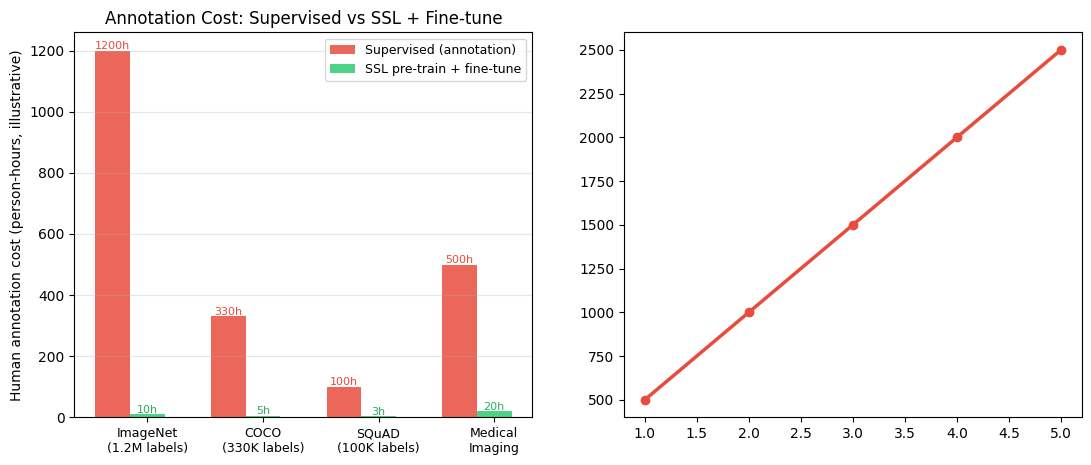

In [2]:
# =============================================================
# Visualisation 2: Sustainability — annotation cost comparison
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Annotation cost ---
ax = axes[0]

tasks = ['ImageNet\n(1.2M labels)', 'COCO\n(330K labels)', 'SQuAD\n(100K labels)', 'Medical\nImaging']
supervised_cost = [1200, 330, 100, 500]  # arbitrary units (person-hours)
ssl_cost        = [0, 0, 0, 0]  # SSL needs 0 annotation
fine_tune_cost  = [10, 5, 3, 20]  # only fine-tune labels needed

x = np.arange(len(tasks))
width = 0.3

bars1 = ax.bar(x - width, supervised_cost, width, label='Supervised (annotation)',
               color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x, fine_tune_cost, width, label='SSL pre-train + fine-tune',
               color='#2ecc71', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())}h', ha='center', fontsize=8, color='#e74c3c')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5,
            f'{int(h)}h', ha='center', fontsize=8, color='#27ae60')

ax.set_xticks(x); ax.set_xticklabels(tasks, fontsize=9)
ax.set_ylabel('Human annotation cost (person-hours, illustrative)')
ax.set_title('Annotation Cost: Supervised vs SSL + Fine-tune')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- Right: Reuse of pre-trained model ---
ax2 = axes[1]

downstream_tasks = 5
from_scratch   = [500] * downstream_tasks   # each task: full training from scratch
ssl_pretrain   = [800]                        # one-time SSL pre-training
ssl_finetune   = [20] * downstream_tasks      # cheap fine-tuning per task

x_tasks = np.arange(1, downstream_tasks + 1)
cumulative_scratch = np.cumsum(from_scratch)
cumulative_ssl     = np.array(ssl_pretrain[0] + sum(ssl_finetune[:i+1])
                               for i in range(downstream_tasks))

ax2.plot(x_tasks, cumulative_scratch, 'o-', color='#e74c3c', linewidth=2.5,
         label='Train from scratch per task')
ax2.plot(x_tasks, cumulative_ssl, 's-', color='#2ecc71', linewidth=2.5,
         label='SSL pre-train once + cheap fine-tune')
ax2.axhline(ssl_pretrain[0], color='gray', linestyle=':', alpha=0.5, linewidth=1,
            label=f'SSL pre-training cost ({ssl_pretrain[0]} units)')

ax2.fill_between(x_tasks, cumulative_scratch, cumulative_ssl,
                  alpha=0.15, color='#27ae60', label='Cumulative savings')

ax2.set_xlabel('Number of downstream tasks')
ax2.set_ylabel('Cumulative compute cost (units)')
ax2.set_title('SSL Amortises Pre-training Cost\nAcross Many Downstream Tasks')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('SSL and AI Sustainability: Less Annotation + Shared Compute',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

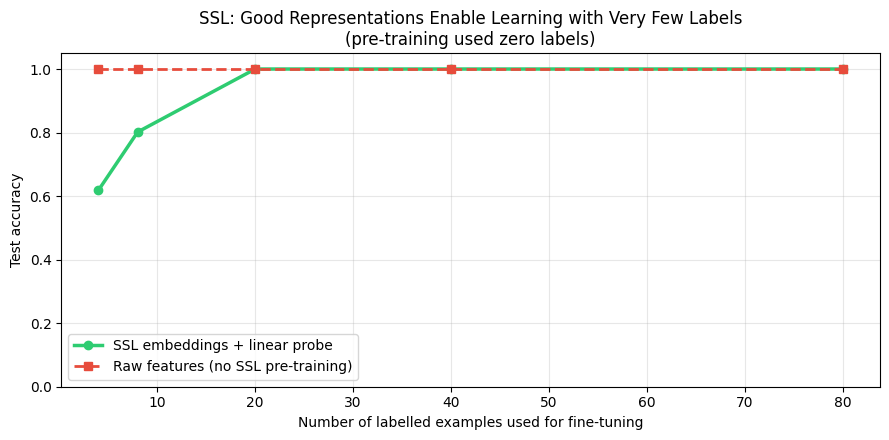

SSL enables high accuracy with few labels — sustainable AI development
SSL with just 4 labels (1 per class): 61.9%
Raw features with same 4 labels:       100.0%


In [4]:
# =============================================================
# Demo: SimCLR-style SSL — encoder learns structure WITHOUT labels
# Downstream: use representations for classification with FEW labels
# =============================================================
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

torch.manual_seed(0); np.random.seed(0)

# 4 classes, 16-dim space — labels HIDDEN during SSL
N_CLASS, N_PER, DIM = 4, 60, 16
means = torch.randn(N_CLASS, DIM) * 4
X_all = torch.cat([means[c] + torch.randn(N_PER, DIM) * 0.8 for c in range(N_CLASS)])
y_all = np.repeat(np.arange(N_CLASS), N_PER)

def augment(x, noise=0.25):
    return x + torch.randn_like(x) * noise

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(DIM, 32), nn.ReLU(),
            nn.Linear(32, 8)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def nt_xent(z1, z2, tau=0.5):
    N = z1.size(0)
    z = torch.cat([z1, z2])
    sim = (z @ z.T) / tau
    sim.fill_diagonal_(-1e9)
    labels = torch.cat([torch.arange(N)+N, torch.arange(N)])
    return F.cross_entropy(sim, labels)

# --- SSL pre-training (NO labels) ---
enc = Encoder()
opt = torch.optim.Adam(enc.parameters(), lr=3e-3)
for _ in range(400):
    z1 = enc(augment(X_all))
    z2 = enc(augment(X_all))
    loss = nt_xent(z1, z2)
    opt.zero_grad(); loss.backward(); opt.step()

# --- Downstream: supervised fine-tune with VERY FEW labels ---
with torch.no_grad():
    emb = enc(X_all).numpy()

results = {'n_labels': [], 'ssl_acc': [], 'random_acc': []}

for n_per_class in [1, 2, 5, 10, 20, 60]:
    # Pick n_per_class labelled examples per class
    train_idx = []
    for c in range(N_CLASS):
        class_idx = np.where(y_all == c)[0]
        train_idx.extend(class_idx[:n_per_class])
    test_idx = [i for i in range(len(y_all)) if i not in train_idx]

    # Skip if no test samples remain (e.g. n_per_class == N_PER uses all data)
    if len(test_idx) == 0:
        continue

    X_tr, y_tr = emb[train_idx], y_all[train_idx]
    X_te, y_te = emb[test_idx],  y_all[test_idx]

    # Linear probe on SSL embeddings
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(X_tr, y_tr)
    ssl_acc = accuracy_score(y_te, clf.predict(X_te))

    # Baseline: train logistic regression on raw features (no SSL)
    clf_raw = LogisticRegression(max_iter=1000, C=1.0)
    clf_raw.fit(X_all[train_idx].numpy(), y_tr)
    raw_acc = accuracy_score(y_te, clf_raw.predict(X_all[test_idx].numpy()))

    results['n_labels'].append(n_per_class * N_CLASS)
    results['ssl_acc'].append(ssl_acc)
    results['random_acc'].append(raw_acc)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(results['n_labels'], results['ssl_acc'], 'o-', color='#2ecc71',
        linewidth=2.5, label='SSL embeddings + linear probe')
ax.plot(results['n_labels'], results['random_acc'], 's--', color='#e74c3c',
        linewidth=2, label='Raw features (no SSL pre-training)')
ax.set_xlabel('Number of labelled examples used for fine-tuning')
ax.set_ylabel('Test accuracy')
ax.set_title('SSL: Good Representations Enable Learning with Very Few Labels\n'
             '(pre-training used zero labels)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print('SSL enables high accuracy with few labels — sustainable AI development')
print(f'SSL with just {N_CLASS} labels (1 per class): {results["ssl_acc"][0]:.1%}')
print(f'Raw features with same {N_CLASS} labels:       {results["random_acc"][0]:.1%}')

## Exam Quick-Reference

**(a-i) SSL vs Supervised Learning:**
- Supervised: external human labels; objective = optimise target task directly
- SSL: auto-generated labels from data structure; objective = solve pretext task to learn transferable representations
- Key diff: source of supervision (external human labels vs internal data structure)

**(a-ii) SSL vs Unsupervised Learning:**
- Both avoid human labels, but different goals
- Unsupervised: model data distribution (cluster/compress) — no fixed predictive target
- SSL: solve a specific predictive pretext task designed to produce transferable representations
- Key diff: SSL has a defined prediction objective; unsupervised does not

**(b) Sustainability:**
SSL reduces annotation costs by learning from free unlabelled data, and amortises the cost of pre-training across many downstream tasks — less total compute and human labour per deployed AI application.